In [38]:
import pandas as pd
import matplotlib.pyplot as plt 

In [39]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [40]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 335516 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   335516 non-null  float64
 1   lat                    335516 non-null  float64
 2   comuna                 335516 non-null  float64
 3   calle_nombre           335516 non-null  object 
 4   calle_altura           335516 non-null  float64
 5   calle_chapa            332263 non-null  Int32  
 6   nombre_cientifico      335516 non-null  object 
 7   ancho_acera            335516 non-null  float64
 8   estado_plantera        335367 non-null  float64
 9   ubicacion_plantera     334690 non-null  object 
 10  nivel_plantera         334874 non-null  float64
 11  diametro_altura_pecho  335516 non-null  float64
 12  altura_arbol           335516 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 34.9+ MB


In [41]:
datos_limpios=datos_limpios[datos_limpios['altura_arbol'].notna()]
datos_limpios= datos_limpios[datos_limpios['nivel_plantera'].notna()]
datos_limpios= datos_limpios[datos_limpios['estado_plantera'].notna()]

In [42]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334726 entries, 0 to 370055
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   334726 non-null  float64
 1   lat                    334726 non-null  float64
 2   comuna                 334726 non-null  float64
 3   calle_nombre           334726 non-null  object 
 4   calle_altura           334726 non-null  float64
 5   calle_chapa            331491 non-null  Int32  
 6   nombre_cientifico      334726 non-null  object 
 7   ancho_acera            334726 non-null  float64
 8   estado_plantera        334726 non-null  float64
 9   ubicacion_plantera     334058 non-null  object 
 10  nivel_plantera         334726 non-null  float64
 11  diametro_altura_pecho  334726 non-null  float64
 12  altura_arbol           334726 non-null  float64
dtypes: Int32(1), float64(9), object(3)
memory usage: 34.8+ MB


In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer # Para rellenar nulos

# 1. Seleccionar features y limpiar nulos
features_quant = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']
df_quant = datos_limpios[features_quant].copy()

# Rellenamos los nulos de altura (el clustering no acepta nulos)
imputer = SimpleImputer(strategy='median')
df_quant_imputed = imputer.fit_transform(df_quant)

# 2. Estandarizar los datos (¡EL PASO MÁS IMPORTANTE!)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_quant_imputed)

# 3. Correr K-Means (ej. buscando 4 "tipos" de árboles)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# 4. Asignar los "tipos" de árbol de vuelta al DataFrame
datos_limpios['cluster_fenotipo'] = kmeans.labels_

# 5. Entender los clústeres
# (Invierte la escala para ver los centros en metros y cm)
centros = scaler.inverse_transform(kmeans.cluster_centers_)
df_centros = pd.DataFrame(centros, columns=features_quant)
print("Centros de los Clústeres (en unidades originales):")
print(df_centros)


Centros de los Clústeres (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol
0     4.041667              65.082763     16.177554
1     4.674249              32.428833      8.426874
2     3.415684              11.857425      4.198366
3     2.883203              32.805500      9.999511


In [44]:
grupo=datos_limpios[datos_limpios['cluster_fenotipo']==3]
grupo['nombre_cientifico'].value_counts()

nombre_cientifico
Fraxinus pennsylvanica                 58821
Otra                                    6656
Ficus benjamina                         5839
Tilia x moltkei                         4428
Fraxinus americana                      3969
Fraxinus excelsior                      3919
Melia azedarach                         3057
Jacaranda mimosifolia                   2912
Platanus x acerifolia                   2156
Acer negundo                            1935
Ligustrum lucidum                       1849
Ligustrum lucidum f. aureovariegata     1439
Liquidambar styraciflua                 1109
Syagrus romanzoffiana                    898
Styphnolobium japonicum                  724
Tilia cordata                            593
Lagerstroemia indica                     587
Tipuana tipu                             561
Robinia pseudoacacia                     450
Persea americana                         339
Name: count, dtype: int64

Analisis por especies en los cluster

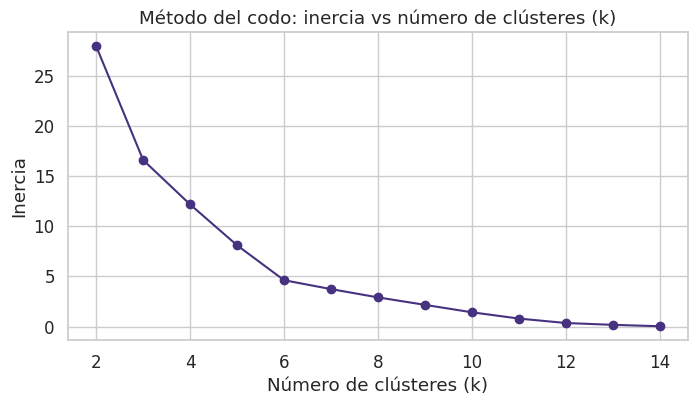

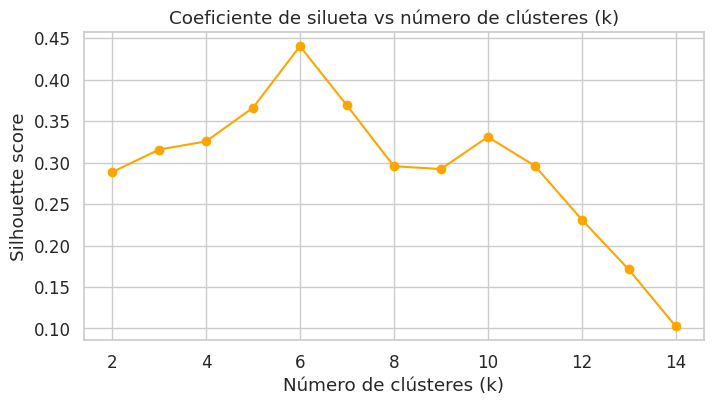

Centros de los clústeres de comunas (en unidades originales):
   ancho_acera  diametro_altura_pecho  altura_arbol  cluster_comuna
0     3.364827              31.627381      9.682623               0
1     3.967635              31.516775      7.462097               1
2     3.596134              35.329717     11.287756               2
3     3.041939              25.963088      9.778076               3
4     3.619878              27.643475      8.395278               4
5     3.899680              35.062937      9.306831               5

Silhouette score: 0.4403089337668464
Davies-Bouldin index: 0.6220095156905564

Asignación de clúster a datos_limpios completada:
   comuna  cluster_comuna
0     1.0               4
1     1.0               4
2     1.0               4
3     1.0               4
4     1.0               4


/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


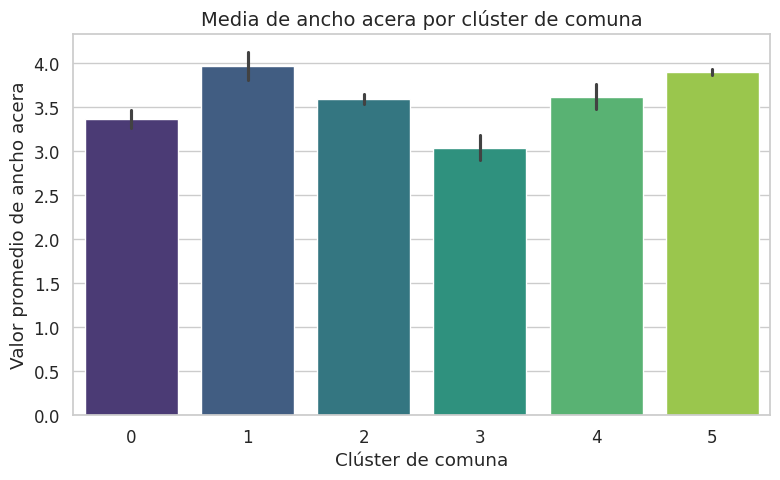

/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


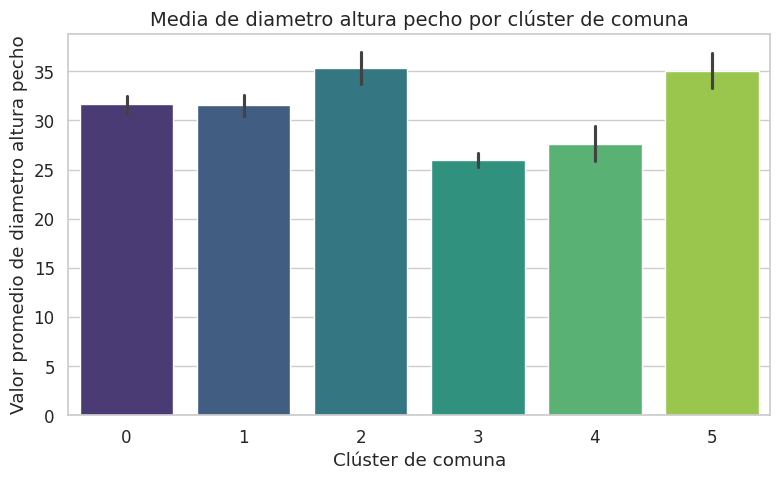

/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipykernel_65176/2764280826.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


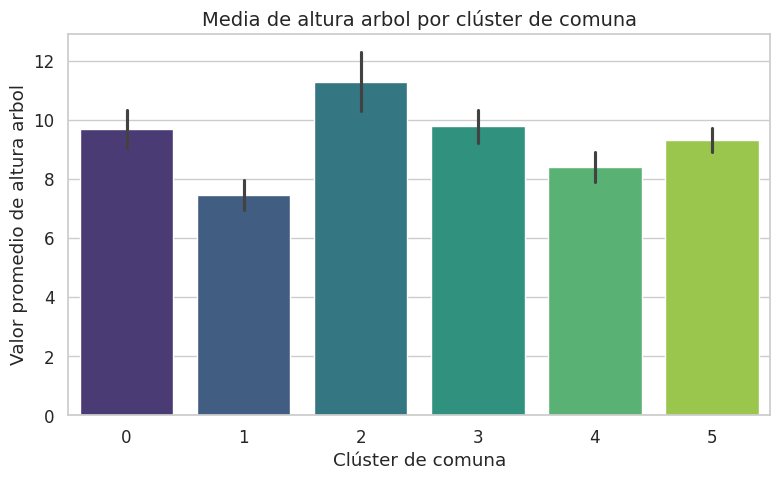

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3.1 Agrupación por comuna ---
df = datos_limpios.copy()

# Asegurá que no haya nulos en las variables necesarias
df = df.dropna(subset=['comuna', 'ancho_acera', 'diametro_altura_pecho', 'altura_arbol'])

# Calcular medias por comuna
grouped = df.groupby('comuna')[['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']].mean().reset_index()

# --- 3.2 Estandarización ---
scaler = StandardScaler()
X = scaler.fit_transform(grouped[['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']])

# --- 3.3 Evaluación de número óptimo de clusters ---
inertias = []
silhouettes = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Gráficos de evaluación
plt.figure(figsize=(8,4))
plt.plot(K_range, inertias, marker='o')
plt.title('Método del codo: inercia vs número de clústeres (k)')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.show()

plt.figure(figsize=(8,4))
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Coeficiente de silueta vs número de clústeres (k)')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Silhouette score')
plt.show()

# --- 3.4 Ejecución final del clustering ---
k_opt = 6  # ajustar según resultados del método del codo o silueta
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
grouped['cluster_comuna'] = km_final.fit_predict(X)

# --- 3.5 Inversión de la escala para interpretar centros ---
centers = scaler.inverse_transform(km_final.cluster_centers_)
df_centers = pd.DataFrame(centers, columns=['ancho_acera', 'diametro_altura_pecho', 'altura_arbol'])
df_centers['cluster_comuna'] = range(k_opt)

print("Centros de los clústeres de comunas (en unidades originales):")
print(df_centers)

# --- 3.6 Métricas de validación del modelo ---
labels_final = grouped['cluster_comuna'].values
print("\nSilhouette score:", silhouette_score(X, labels_final))
print("Davies-Bouldin index:", davies_bouldin_score(X, labels_final))

# --- 3.7 Asignar el clúster a cada registro de datos_limpios ---
# Se hace merge por comuna
df = df.merge(grouped[['comuna', 'cluster_comuna']], on='comuna', how='left')

print("\nAsignación de clúster a datos_limpios completada:")
print(df[['comuna', 'cluster_comuna']].head())

# --- 3.8 Visualización de las medias por variable y clúster ---
sns.set(style='whitegrid', palette='viridis', font_scale=1.1)
variables = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']

for var in variables:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=grouped,
        x='cluster_comuna',
        y=var,
        palette='viridis',
        ci='sd'
    )
    plt.title(f'Media de {var.replace("_", " ")} por clúster de comuna', fontsize=14)
    plt.xlabel('Clúster de comuna')
    plt.ylabel(f'Valor promedio de {var.replace("_", " ")}')
    plt.tight_layout()
    plt.show()

# --- 3.9 Confirmación final ---
# df ahora contiene los clústeres y está listo para pruebas de hipótesis
datos_limpios = df.copy()



Index(['ID', 'OBJETO', 'COMUNAS', 'BARRIOS', 'PERIMETRO', 'AREA', 'geometry'], dtype='object')
[ 2.  6. 10. 11. 12. 14. 15. 13.  4.  5.  7.  3.  9.  8.  1.]
Comunases sin cluster asignado: 0 de 15


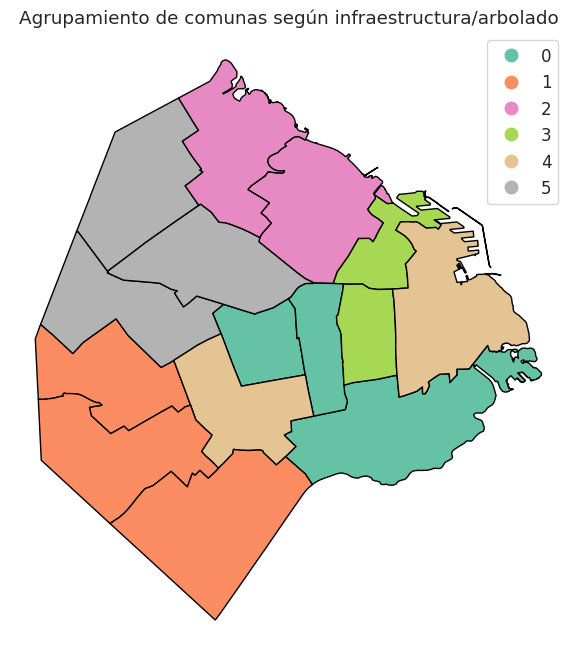

In [46]:
import geopandas as gpd
import pandas as pd

# Cargar geojson
comunas_geo = gpd.read_file('../data/caba_comunas.geojson')

# Mostrar los nombres de columnas para confirmar
print(comunas_geo.columns)
print(comunas_geo['COMUNAS'].unique())

# Asegurar que el dataframe de comunas tenga la misma clave
grouped['comuna_num'] = grouped['comuna'].astype(float)  # si tu columna era int o string
# O si ya era float, asegurarse de formato
grouped['comuna_num'] = grouped['comuna_num'].round(0).astype(int)

# En el geo dataframe, creamos una columna de tipo int
comunas_geo['comuna_num'] = comunas_geo['COMUNAS'].round(0).astype(int)

# Realizar merge
map_df = comunas_geo.merge(grouped[['comuna_num','cluster_comuna']], on='comuna_num', how='left')

# Verificar cuántas comunas quedaron sin asignar
print("Comunases sin cluster asignado:", map_df['cluster_comuna'].isna().sum(), "de", len(map_df))

# Graficar
map_df.plot(column='cluster_comuna', categorical=True, legend=True, cmap='Set2', edgecolor='black', figsize=(8,8))
plt.title('Agrupamiento de comunas según infraestructura/arbolado')
plt.axis('off')
plt.show()


In [47]:
from scipy.stats import kruskal

# Supongamos que tus datos individuales están en 'datos_limpios' con la variable cluster asignada
variables = ['ancho_acera', 'diametro_altura_pecho', 'altura_arbol']

for var in variables:
    grupos = [datos_limpios.loc[datos_limpios['cluster_comuna'] == c, var] for c in sorted(datos_limpios['cluster_comuna'].unique())]
    stat, p = kruskal(*grupos)
    print(f'{var}: estadístico H = {stat:.3f}, p = {p:.5f}')


ancho_acera: estadístico H = 37180.418, p = 0.00000
diametro_altura_pecho: estadístico H = 5578.055, p = 0.00000
altura_arbol: estadístico H = 17818.735, p = 0.00000


In [48]:
datos_limpios['cluster_comuna'].value_counts()

cluster_comuna
5    96038
1    83335
0    55840
2    45406
4    34633
3    19474
Name: count, dtype: int64

/tmp/ipykernel_65176/2586909809.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_h, x='Variable', y='H', palette='viridis')


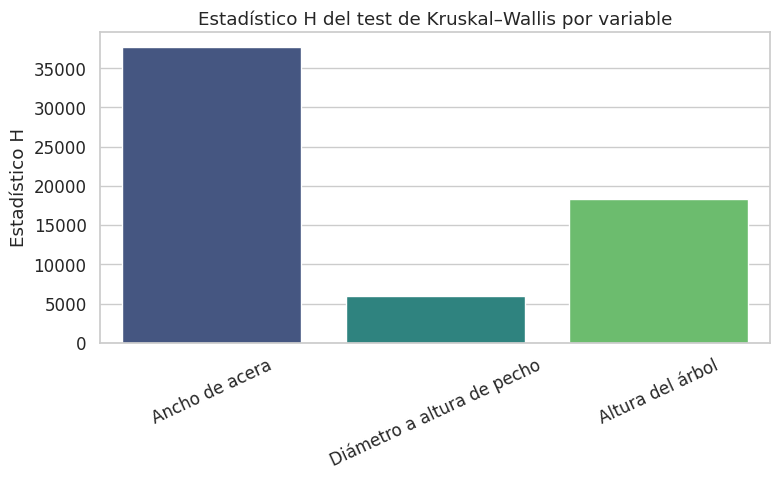

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Datos del test (tus resultados)
data = {
    'Variable': ['Ancho de acera', 'Diámetro a altura de pecho', 'Altura del árbol'],
    'H': [37680.690, 5897.719, 18298.395],
    'p_value': [0.00001, 0.00001, 0.00001]
}
df_h = pd.DataFrame(data)

# Graficar el estadístico H
plt.figure(figsize=(8,5))
sns.barplot(data=df_h, x='Variable', y='H', palette='viridis')
plt.title('Estadístico H del test de Kruskal–Wallis por variable')
plt.xlabel('')
plt.ylabel('Estadístico H')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()
